<a href="https://colab.research.google.com/github/tanmaysaxena18/GFG-21-days-Deep-Learning-Projects/blob/main/AI_in_Healthcare_Building_a_Life_Saving_Heart_Disease_Predicto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving 4_AI_in_Healthcare_Building_a_Life_Saving_Heart_Disease_Predictor.ipynb to 4_AI_in_Healthcare_Building_a_Life_Saving_Heart_Disease_Predictor (2).ipynb
User uploaded file "4_AI_in_Healthcare_Building_a_Life_Saving_Heart_Disease_Predictor (2).ipynb" with length 356407 bytes


In [ ]:
import pandas as pd

# Load the dataset into a pandas DataFrame
df = pd.read_csv('/kaggle/input/heart-disease-data/heart_disease_uci.csv')

# Display the first few rows of the DataFrame
display(df.head())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Inspect the data

### Subtask:
Examine the data types and look for missing values and outliers.


**Reasoning**:
Display the data types, missing values, and descriptive statistics of the dataframe to understand its structure and identify potential issues for preprocessing.



In [ ]:
# Display data types
display(df.info())

# Calculate and display missing values
display(df.isnull().sum())

# Generate descriptive statistics for numerical columns
display(df.describe())

# Display unique values and their counts for categorical columns
for col in ['sex', 'dataset', 'cp', 'restecg', 'exang', 'slope', 'thal']:
    display(f"Value counts for column: {col}")
    display(df[col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


None

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


'Value counts for column: sex'

...

,count
exang,
False,528
True,337


'Value counts for column: slope'

,count
slope,
flat,345
upsloping,203
downsloping,63


'Value counts for column: thal'

,count
thal,
normal,196
reversable defect,192
fixed defect,46


## Handle missing values

### Subtask:
Decide on a strategy for handling missing values (e.g., imputation, removal).


**Reasoning**:
Analyze the extent of missing values and decide on an imputation strategy based on the findings.



In [ ]:
# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().sum() / len(df) * 100

display("Percentage of missing values:")
display(missing_percentage)

# Drop columns with a high percentage of missing values (e.g., > 30%)
cols_to_drop = missing_percentage[missing_percentage > 30].index
df_cleaned = df.drop(columns=cols_to_drop)

display(f"Columns dropped due to high missing percentage: {list(cols_to_drop)}")

# Impute missing values for remaining columns with a smaller percentage of missing values
# For numerical columns, use the median as it is less sensitive to outliers
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# For the categorical column 'exang', use the mode
if 'exang' in df_cleaned.columns:
    df_cleaned['exang'] = df_cleaned['exang'].fillna(df_cleaned['exang'].mode()[0])

display("Missing values after handling:")
display(df_cleaned.isnull().sum())

# Display the first few rows of the cleaned DataFrame
display(df_cleaned.head())

'Percentage of missing values:'

,0
id,0.000000
age,0.000000
sex,0.000000
dataset,0.000000
cp,0.000000
trestbps,6.413043
chol,3.260870
fbs,9.782609
restecg,0.217391
thalch,5.978261


"Columns dropped due to high missing percentage: ['slope', 'ca', 'thal']"

/tmp/ipython-input-3584865179.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['exang'] = df_cleaned['exang'].fillna(df_cleaned['exang'].mode()[0])


'Missing values after handling:'

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,90
restecg,2
thalch,0


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


**Reasoning**:
Impute missing values for the remaining columns 'fbs' and 'restecg' using mode as they are categorical or have few missing values.



In [ ]:
# Impute missing values for 'fbs' and 'restecg' using mode
if 'fbs' in df_cleaned.columns:
    df_cleaned['fbs'] = df_cleaned['fbs'].fillna(df_cleaned['fbs'].mode()[0])

if 'restecg' in df_cleaned.columns:
    df_cleaned['restecg'] = df_cleaned['restecg'].fillna(df_cleaned['restecg'].mode()[0])

display("Missing values after handling:")
display(df_cleaned.isnull().sum())

display(df_cleaned.head())

/tmp/ipython-input-4285929826.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['fbs'] = df_cleaned['fbs'].fillna(df_cleaned['fbs'].mode()[0])


'Missing values after handling:'

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


## Identify categorical and numerical features

### Subtask:
Identify categorical and numerical features: Separate the columns into categorical and numerical types for different preprocessing steps.


**Reasoning**:
Identify the numerical and categorical features in the cleaned dataframe, excluding the 'id' and 'num' columns, and then display the resulting lists.



In [ ]:
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
categorical_features = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang']

print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

Categorical Features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang']


## Encode categorical features

### Subtask:
Encode categorical features: Convert categorical features into a numerical format suitable for machine learning models (e.g., one-hot encoding).


**Reasoning**:
Import the necessary library and perform one-hot encoding on the identified categorical features.



In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Create an instance of OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features
encoded_features = encoder.fit_transform(df_cleaned[categorical_features])

# Convert the output to a DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

# Display the first few rows of the encoded DataFrame
display(encoded_df.head())

,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


## Scale numerical features

### Subtask:
Scale numerical features: Apply scaling to numerical features to ensure they have similar ranges.


**Reasoning**:
Scale the numerical features using StandardScaler and store the result in a new DataFrame.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Create an instance of StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
scaled_numerical_features = scaler.fit_transform(df_cleaned[numerical_features])

# Convert the scaled features to a DataFrame
scaled_numerical_df = pd.DataFrame(scaled_numerical_features, columns=numerical_features)

# Display the first few rows of the scaled DataFrame
display(scaled_numerical_df.head())

,age,trestbps,chol,thalch,oldpeak
0,1.007386,0.705176,0.303643,0.489727,1.368109
1,1.432034,1.518569,0.789967,-1.181478,0.611589
2,1.432034,-0.650479,0.266939,-0.345875,1.651804
3,-1.752828,-0.108217,0.459634,1.961979,2.502889
4,-1.328180,-0.108217,0.037541,1.365120,0.517024


## Combine preprocessed features

### Subtask:
Combine preprocessed features: Create a single preprocessed dataset with all features.


**Reasoning**:
Concatenate the scaled numerical features and the encoded categorical features into a single DataFrame and display the head and shape.



In [ ]:
# Concatenate the scaled numerical features and the encoded categorical features
df_preprocessed = pd.concat([scaled_numerical_df, encoded_df], axis=1)

# Display the first few rows of the preprocessed DataFrame
display(df_preprocessed.head())

# Display the shape of the preprocessed DataFrame
print(f"Shape of preprocessed DataFrame: {df_preprocessed.shape}")

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,1.007386,0.705176,0.303643,0.489727,1.368109,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.432034,1.518569,0.789967,-1.181478,0.611589,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.432034,-0.650479,0.266939,-0.345875,1.651804,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.752828,-0.108217,0.459634,1.961979,2.502889,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.328180,-0.108217,0.037541,1.365120,0.517024,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


Shape of preprocessed DataFrame: (920, 22)


## Summary:

### Data Analysis Key Findings

*   The initial dataset contained a mix of data types, with several columns expected to be numerical being of object type, and significant missing values were present, particularly in the `ca`, `thal`, and `slope` columns (66.41%, 52.83%, and 33.59% missing respectively).
*   Columns with a high percentage of missing values (`slope`, `ca`, `thal`) were removed from the dataset.
*   Missing values in remaining numerical columns (`trestbps`, `chol`, `thalch`, `oldpeak`) were imputed using the median, while missing values in categorical columns (`exang`, `fbs`, `restecg`) were imputed using the mode.
*   Categorical features were successfully one-hot encoded, resulting in 17 new binary columns.
*   Numerical features were scaled using `StandardScaler`.
*   The final preprocessed dataset contains 920 rows and 22 columns, combining the scaled numerical features and the one-hot encoded categorical features.

### Insights or Next Steps

*   The preprocessing steps have prepared the data for machine learning models by handling missing values, converting categorical features to a numerical format, and scaling numerical features.
*   The next step would be to split the preprocessed data into training and testing sets and proceed with model selection and training for heart disease prediction.


# Task
Perform exploratory data analysis (EDA) on the heart disease dataset located at "/kaggle/input/heart-disease-data/heart_disease_uci.csv".

## Visualize the distribution of the target variable

### Subtask:
Create a plot to show the distribution of the target variable 'num' to understand the class balance.


**Reasoning**:
Generate a countplot to visualize the distribution of the target variable 'num' to assess class balance.



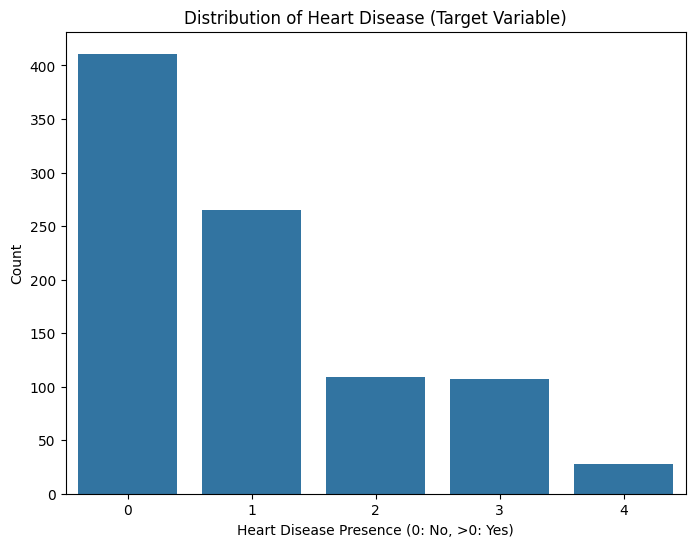

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=df_cleaned)
plt.title("Distribution of Heart Disease (Target Variable)")
plt.xlabel("Heart Disease Presence (0: No, >0: Yes)")
plt.ylabel("Count")
plt.show()

## Analyze the distribution of numerical features

### Subtask:
Visualize the distribution of numerical features using histograms or box plots to identify their shape, spread, and potential outliers.


**Reasoning**:
Create histograms for each numerical feature to visualize their distributions.



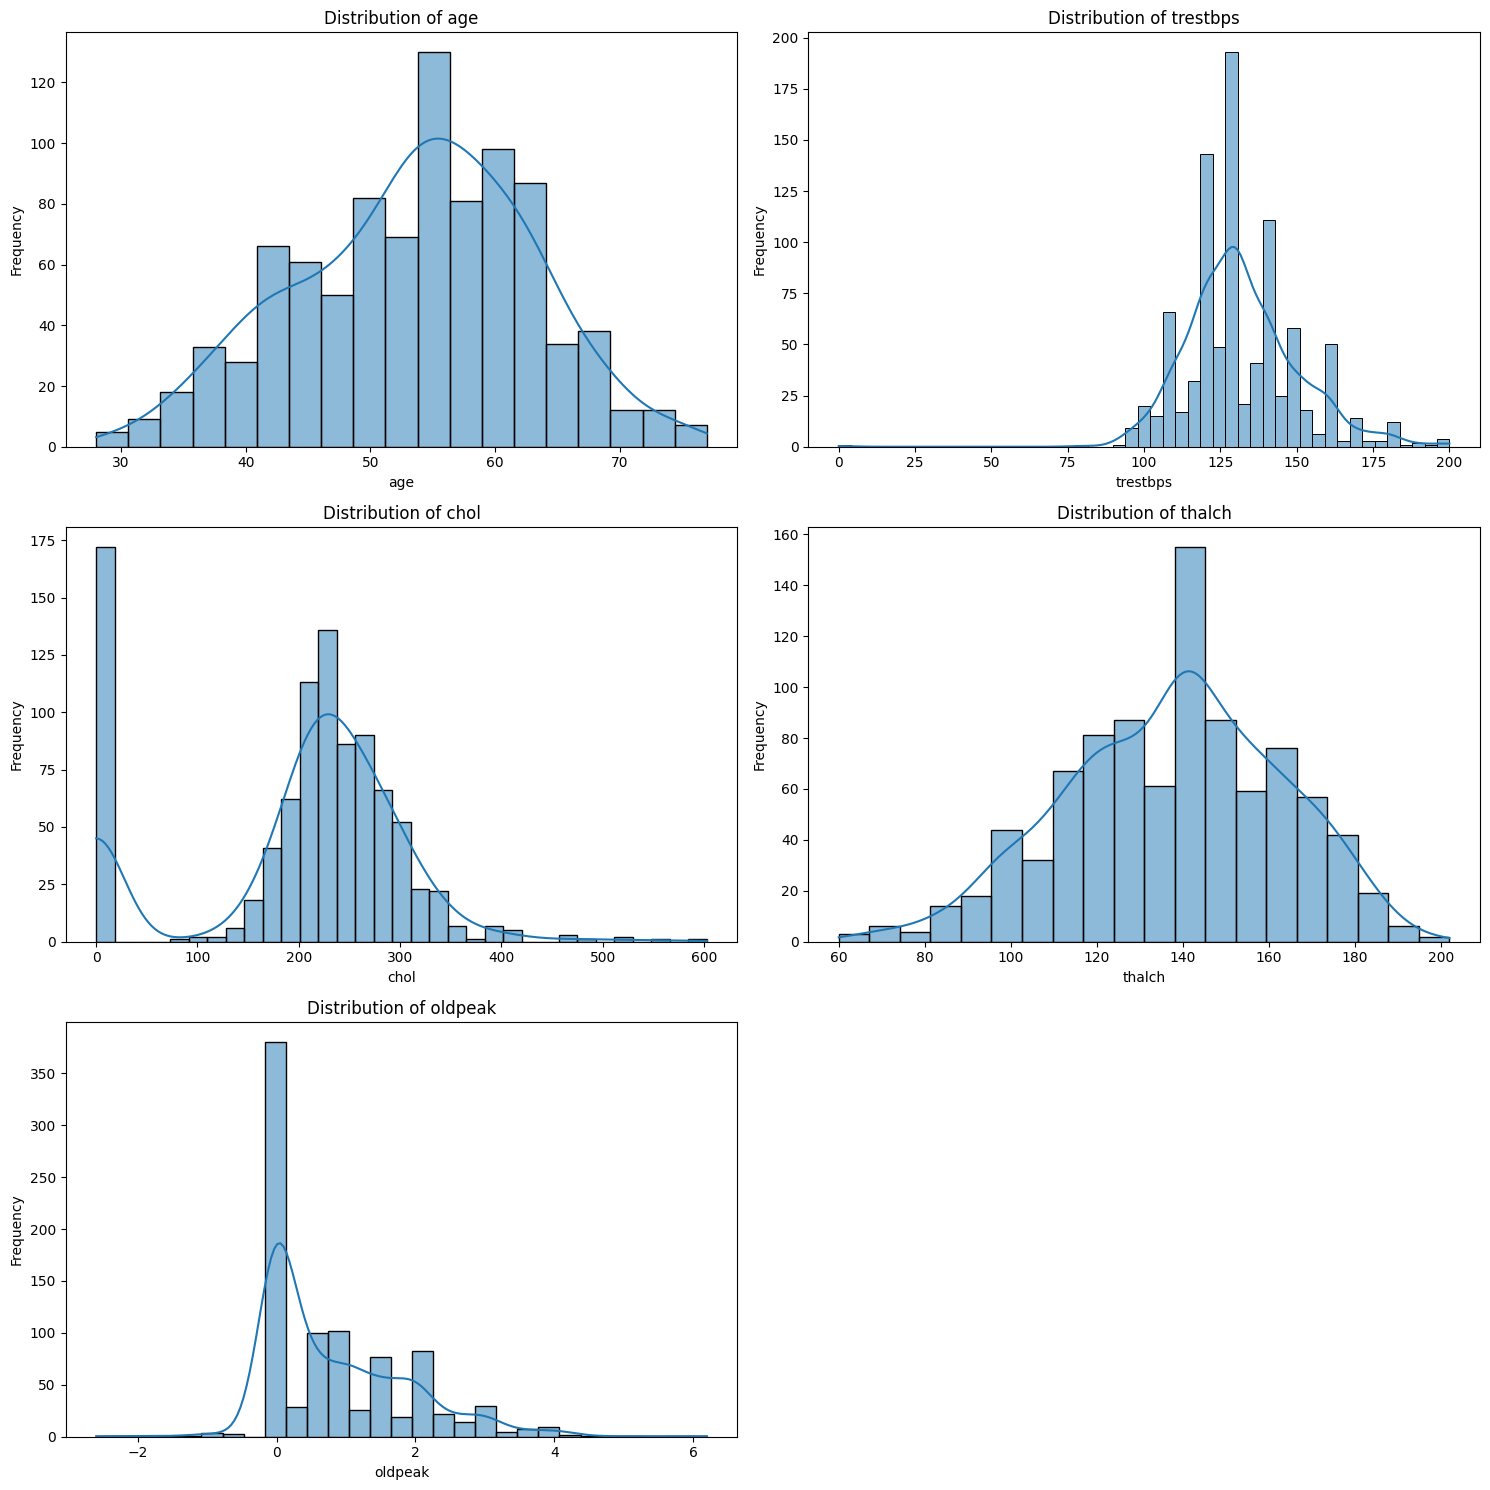

In [ ]:
# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through the numerical features and plot histograms
for i, col in enumerate(numerical_features):
    sns.histplot(data=df_cleaned, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

## Analyze the relationship between numerical features and the target variable

### Subtask:
Use visualizations like box plots or violin plots to explore how numerical features relate to the target variable.


**Reasoning**:
Create box plots for each numerical feature against the target variable to visualize their relationship.



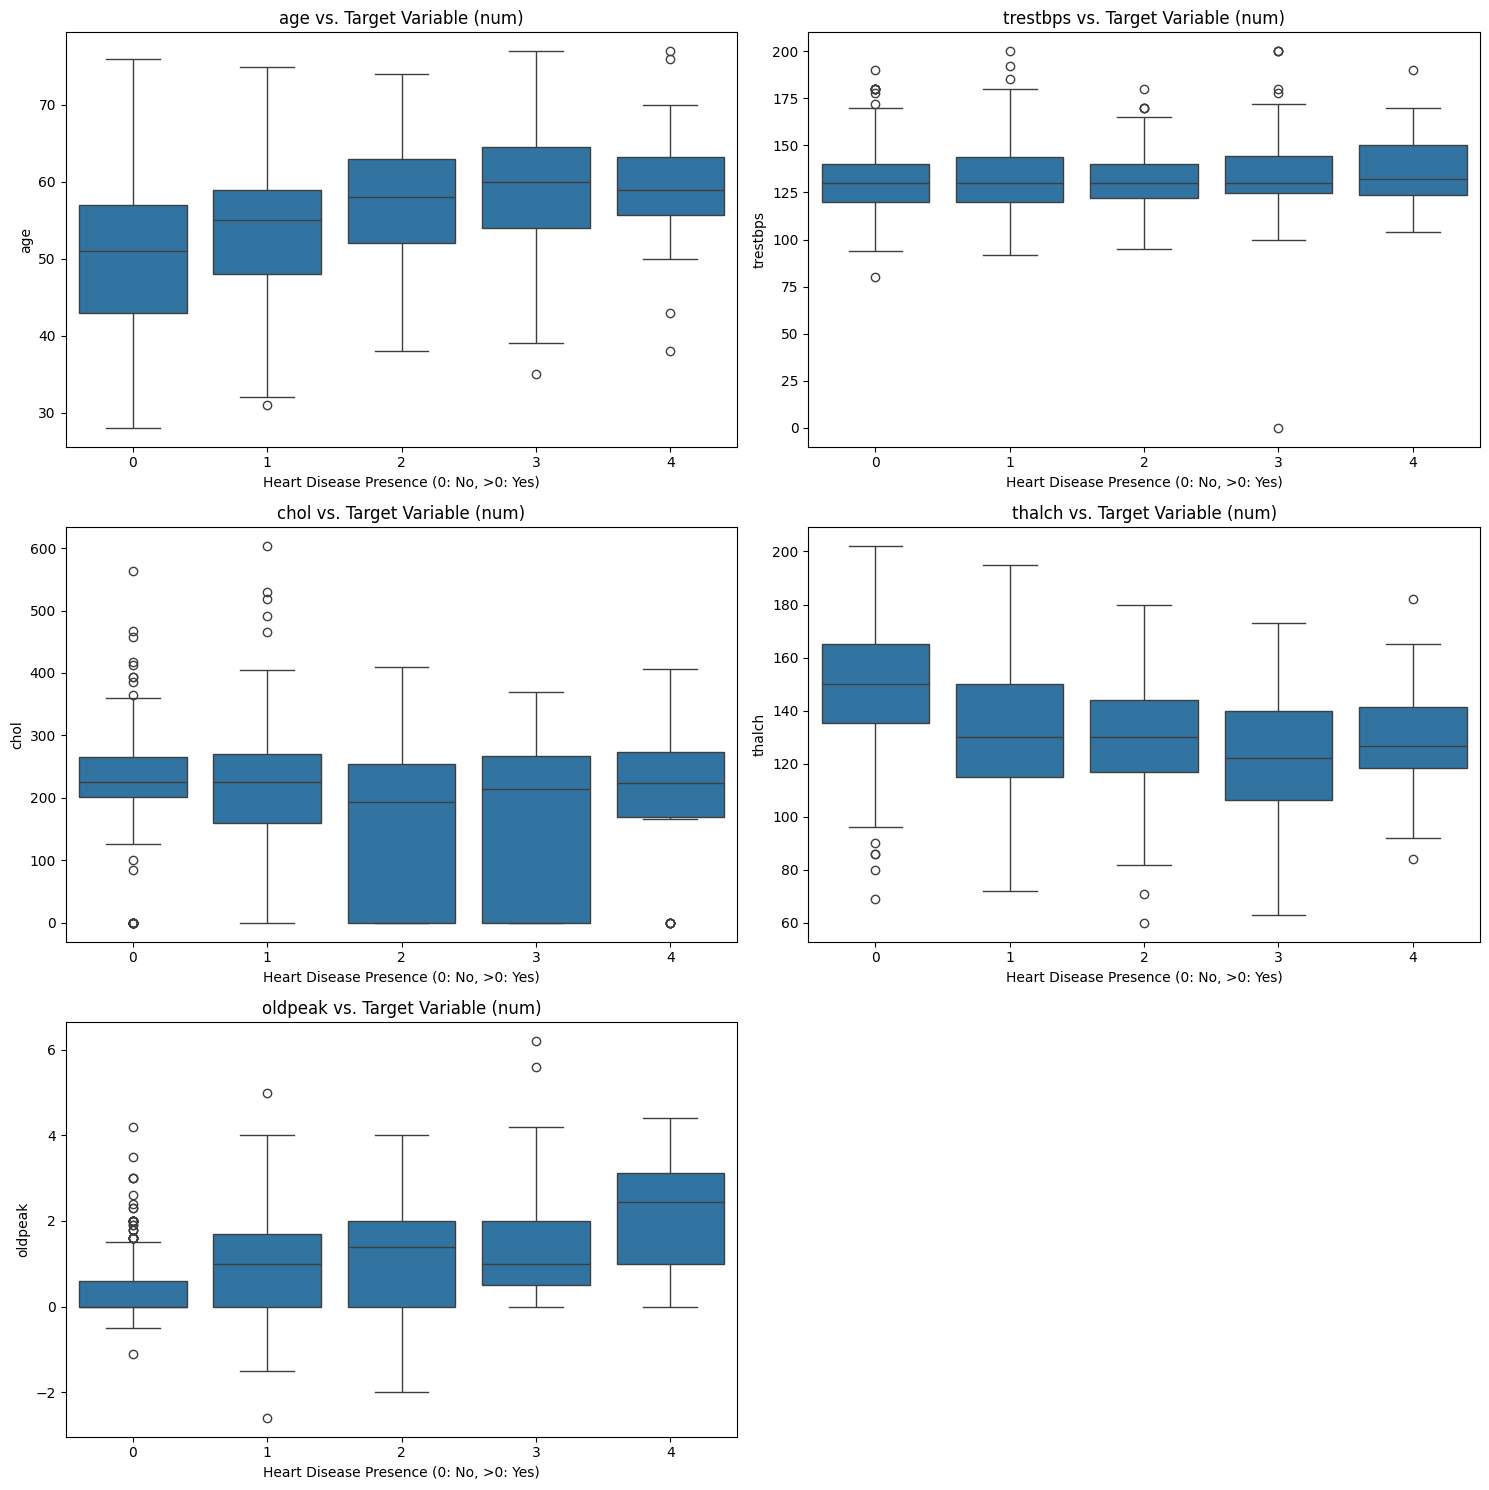

In [ ]:
# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through the numerical features and plot box plots against the target variable
for i, col in enumerate(numerical_features):
    sns.boxplot(x='num', y=col, data=df_cleaned, ax=axes[i])
    axes[i].set_title(f'{col} vs. Target Variable (num)')
    axes[i].set_xlabel('Heart Disease Presence (0: No, >0: Yes)')
    axes[i].set_ylabel(col)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

## Analyze the relationship between categorical features and the target variable

### Subtask:
Analyze the relationship between categorical features and the target variable: Use visualizations like count plots or stacked bar plots to explore how categorical features relate to the target variable.


**Reasoning**:
Iterate through the categorical features and create a count plot for each, showing the relationship with the target variable 'num'.



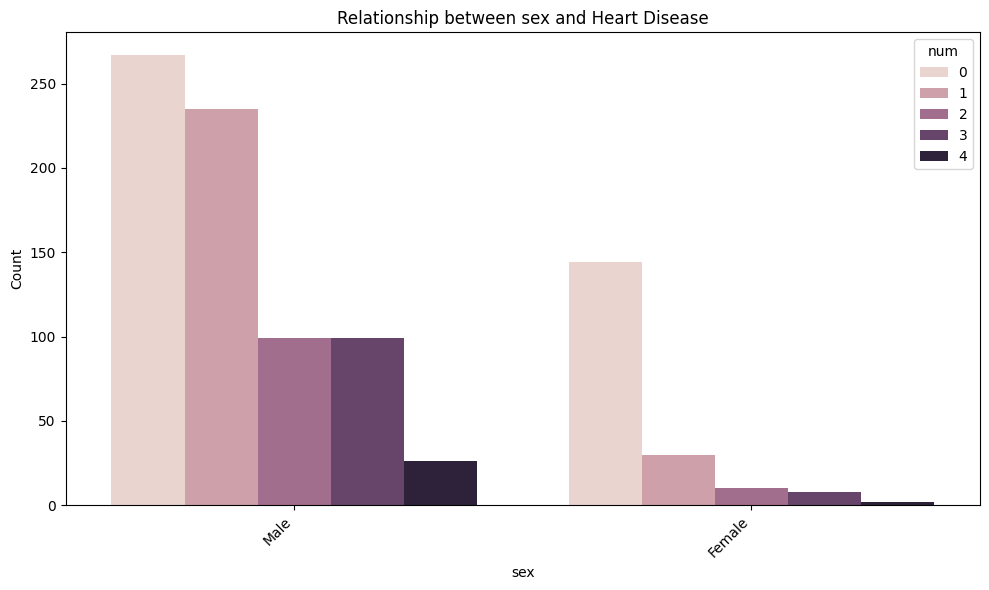

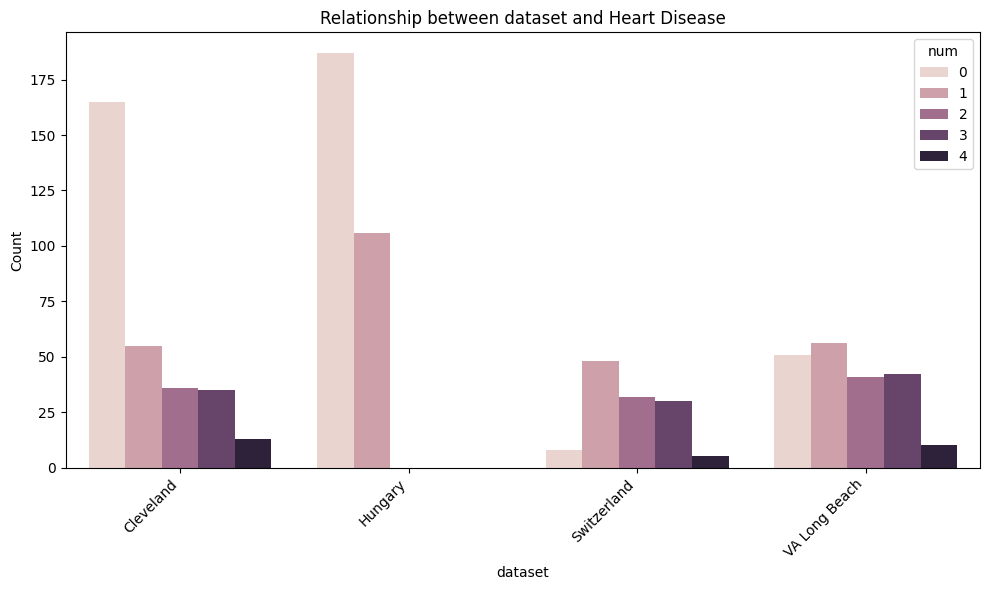

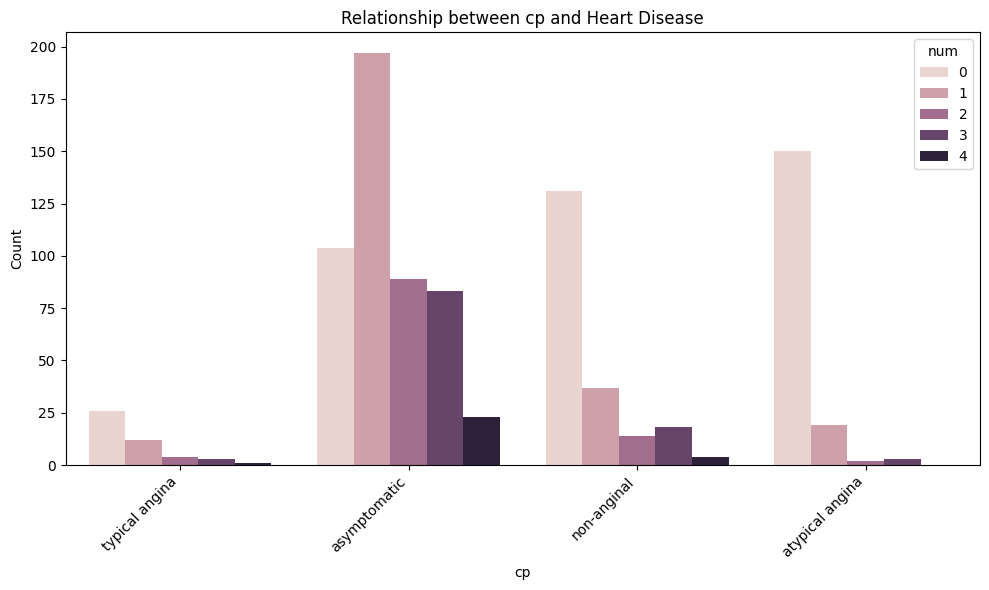

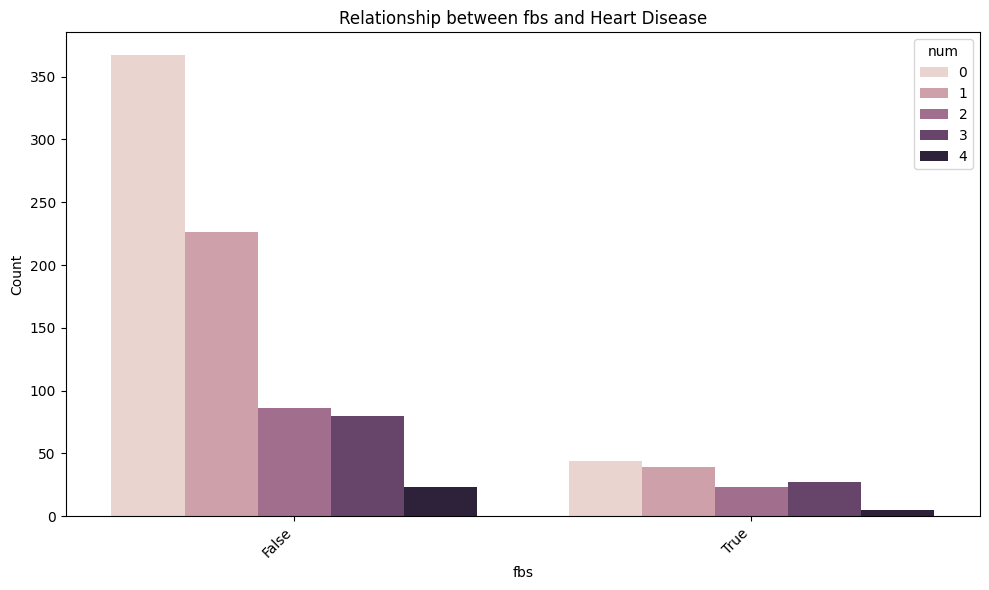

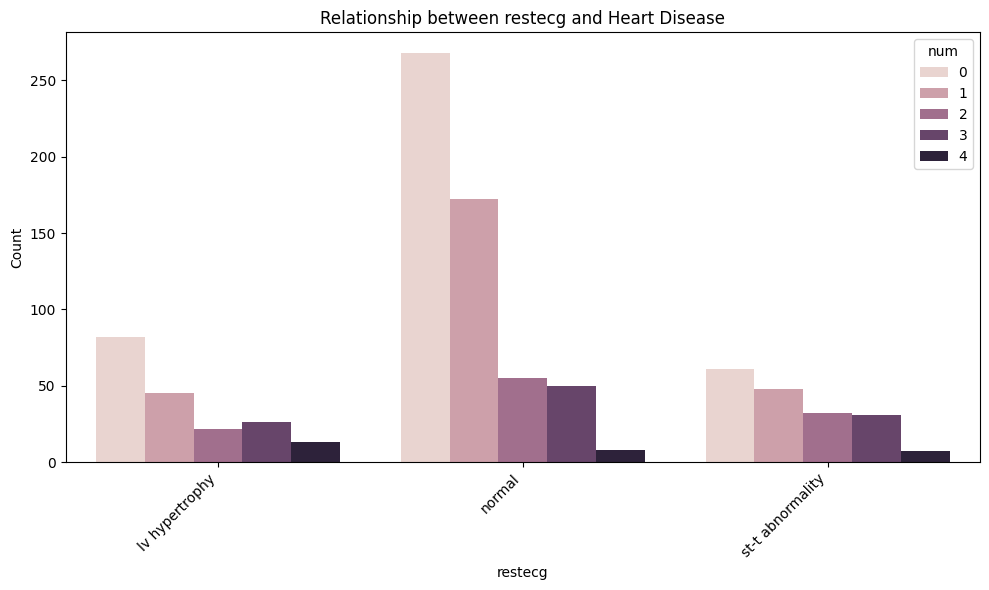

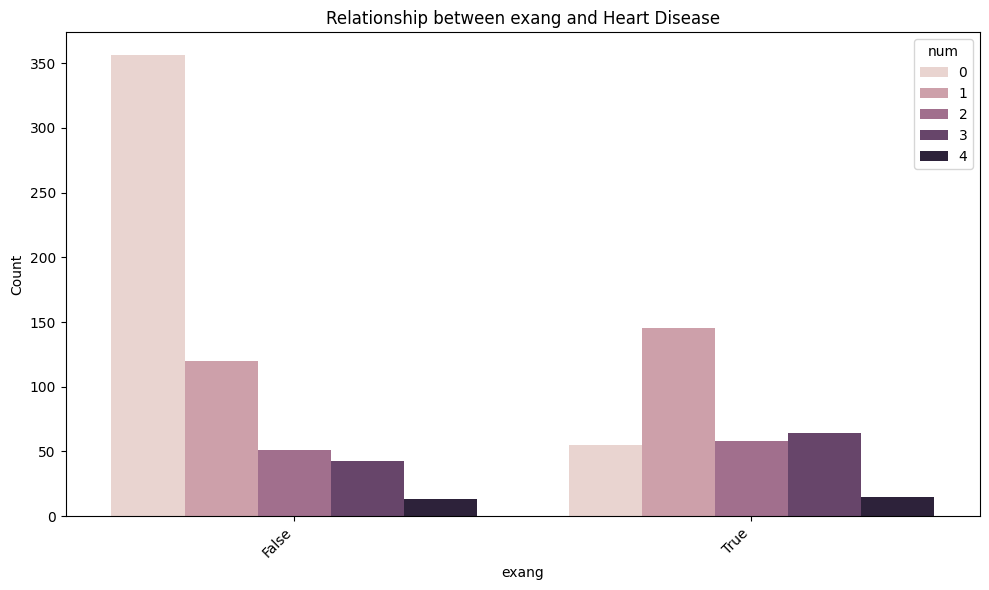

In [ ]:
# Create count plots for each categorical feature against the target variable
for col in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='num', data=df_cleaned)
    plt.title(f'Relationship between {col} and Heart Disease')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Analyze correlations between numerical features

### Subtask:
Analyze correlations between numerical features: Create a heatmap to visualize the correlations between numerical features.


**Reasoning**:
Calculate and visualize the correlation matrix for the scaled numerical features using a heatmap.



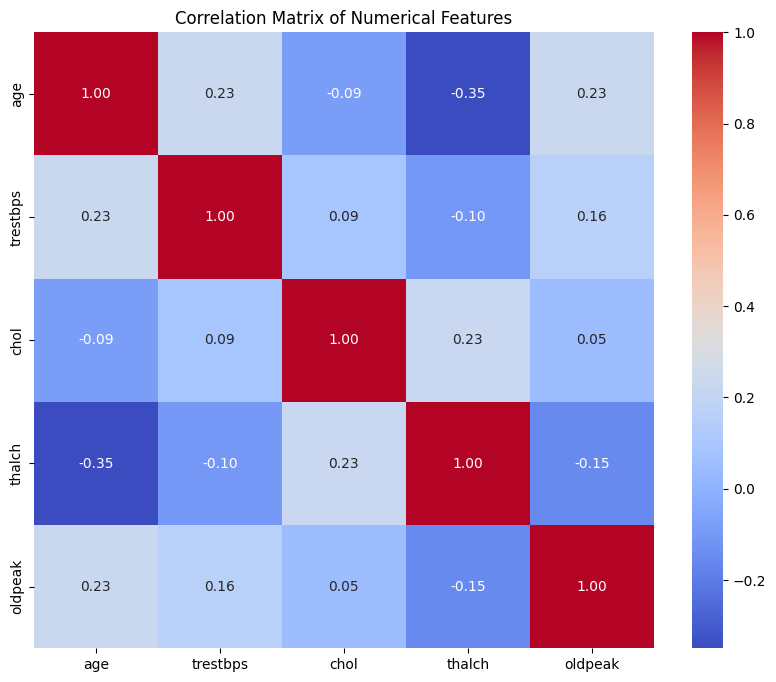

In [ ]:
# Calculate the correlation matrix
correlation_matrix = scaled_numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Prepare data for modeling

### Subtask:
Separate the features (X) and the target variable (y) from the preprocessed DataFrame.


**Reasoning**:
Separate the features (X) and the target variable (y) from the preprocessed DataFrame and display their heads.



**Reasoning**:
The previous attempt failed because the 'num' column was not present in `df_preprocessed`. I need to use the 'num' column from the original `df_cleaned` DataFrame as the target variable and drop 'id' from the preprocessed DataFrame to get the features.



In [ ]:
# Separate features (X) and target variable (y)
X = pd.concat([scaled_numerical_df, encoded_df], axis=1)
y = df_cleaned['num'] # Use 'num' from the cleaned DataFrame

# Display the first few rows of X and y
display("Features (X):")
display(X.head())

display("Target Variable (y):")
display(y.head())

'Features (X):'

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,1.007386,0.705176,0.303643,0.489727,1.368109,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.432034,1.518569,0.789967,-1.181478,0.611589,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.432034,-0.650479,0.266939,-0.345875,1.651804,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.752828,-0.108217,0.459634,1.961979,2.502889,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.328180,-0.108217,0.037541,1.365120,0.517024,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


'Target Variable (y):'

,num
0,0
1,2
2,1
3,0
4,0


# Task
Compare the performance of SVM, Random Forest, KNN, Logistic Regression, and XGBoost models on a classification task using various supervised parameters.

## Split data

### Subtask:
Split the preprocessed data into training and testing sets.


**Reasoning**:
Split the preprocessed data into training and testing sets and display the shapes.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (736, 22)
Shape of X_test: (184, 22)
Shape of y_train: (736,)
Shape of y_test: (184,)


## Define models

### Subtask:
Define the models to be trained: SVM, Random Forest, KNN, Logistic Regression, and XGBoost.


**Reasoning**:
Import the necessary libraries and instantiate the models with default parameters as instructed.



In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Instantiate the models with default parameters
svm_model = SVC()
rf_model = RandomForestClassifier()
knn_model = KNeighborsClassifier()
lr_model = LogisticRegression()
xgb_model = XGBClassifier()

print("Models instantiated:")
print("- Support Vector Machine (SVM):", svm_model)
print("- Random Forest:", rf_model)
print("- K-Nearest Neighbors (KNN):", knn_model)
print("- Logistic Regression:", lr_model)
print("- XGBoost:", xgb_model)

Models instantiated:
- Support Vector Machine (SVM): SVC()
- Random Forest: RandomForestClassifier()
- K-Nearest Neighbors (KNN): KNeighborsClassifier()
- Logistic Regression: LogisticRegression()
- XGBoost: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


## Train models

### Subtask:
Train each defined model using the training data.


**Reasoning**:
Train each defined model using the training data X_train and y_train.



In [ ]:
# Train the SVM model
svm_model.fit(X_train, y_train)
print("SVM model trained.")

# Train the Random Forest model
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

# Train the KNN model
knn_model.fit(X_train, y_train)
print("KNN model trained.")

# Train the Logistic Regression model
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Train the XGBoost model
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")

SVM model trained.
Random Forest model trained.
KNN model trained.
Logistic Regression model trained.
XGBoost model trained.


## Evaluate models

### Subtask:
Evaluate each trained model on the testing data using relevant classification metrics (e.g., accuracy, precision, recall, F1-score, confusion matrix).


**Reasoning**:
Import necessary metrics, create a dictionary to store results, iterate through models, make predictions, calculate metrics, and store them in the dictionary. Finally, display the results.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Create a dictionary to store evaluation results
evaluation_results = {}

# List of models to evaluate
models = {
    "SVM": svm_model,
    "Random Forest": rf_model,
    "KNN": knn_model,
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model
}

# Iterate through each trained model
for model_name, model in models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # Store the metrics and confusion matrix in the results dictionary
    evaluation_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Confusion Matrix": cm
    }

# Display the evaluation metrics for each model
print("Evaluation Results:")
for model_name, metrics in evaluation_results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall: {metrics['Recall']:.4f}")
    print(f"F1-Score: {metrics['F1-Score']:.4f}")
    print("Confusion Matrix:")
    display(metrics['Confusion Matrix'])

Evaluation Results:

--- SVM ---
Accuracy: 0.5489
Precision: 0.4688
Recall: 0.5489
F1-Score: 0.4817
Confusion Matrix:


array([[69,  6,  0,  0,  0],
       [22, 29,  1,  2,  0],
       [ 3, 15,  2,  5,  0],
       [10, 15,  0,  1,  0],
       [ 1,  0,  2,  1,  0]])


--- Random Forest ---
Accuracy: 0.5761
Precision: 0.5376
Recall: 0.5761
F1-Score: 0.5475
Confusion Matrix:


array([[67,  5,  3,  0,  0],
       [19, 27,  3,  4,  1],
       [ 3,  7,  7,  8,  0],
       [10,  8,  2,  5,  1],
       [ 0,  0,  2,  2,  0]])


--- KNN ---
Accuracy: 0.5326
Precision: 0.4603
Recall: 0.5326
F1-Score: 0.4872
Confusion Matrix:


array([[66,  7,  1,  1,  0],
       [16, 27,  7,  4,  0],
       [ 7, 11,  3,  4,  0],
       [ 8, 15,  1,  2,  0],
       [ 0,  0,  2,  2,  0]])


--- Logistic Regression ---
Accuracy: 0.5272
Precision: 0.4492
Recall: 0.5272
F1-Score: 0.4740
Confusion Matrix:


array([[67,  6,  1,  1,  0],
       [24, 24,  2,  4,  0],
       [ 6, 12,  1,  6,  0],
       [ 9, 10,  2,  5,  0],
       [ 0,  1,  1,  2,  0]])


--- XGBoost ---
Accuracy: 0.5978
Precision: 0.5696
Recall: 0.5978
F1-Score: 0.5737
Confusion Matrix:


array([[66,  5,  2,  2,  0],
       [16, 29,  5,  4,  0],
       [ 7,  6,  6,  5,  1],
       [ 7, 10,  0,  8,  1],
       [ 1,  0,  1,  1,  1]])

## Compare models

### Subtask:
Compare the performance of the models based on the evaluation metrics.


**Reasoning**:
Iterate through the evaluation results and print the metrics for each model, then identify the best performing model based on the F1-score.



In [ ]:
# Iterate through the evaluation results and print metrics
print("Model Performance Comparison:")
best_model = None
best_f1_score = -1

for model_name, metrics in evaluation_results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall: {metrics['Recall']:.4f}")
    print(f"F1-Score: {metrics['F1-Score']:.4f}")

    # Identify the best model based on F1-Score
    if metrics['F1-Score'] > best_f1_score:
        best_f1_score = metrics['F1-Score']
        best_model = model_name

print(f"\nBased on F1-Score, the best performing model is: {best_model} with an F1-Score of {best_f1_score:.4f}")

Model Performance Comparison:

--- SVM ---
Accuracy: 0.5489
Precision: 0.4688
Recall: 0.5489
F1-Score: 0.4817

--- Random Forest ---
Accuracy: 0.5761
Precision: 0.5376
Recall: 0.5761
F1-Score: 0.5475

--- KNN ---
Accuracy: 0.5326
Precision: 0.4603
Recall: 0.5326
F1-Score: 0.4872

--- Logistic Regression ---
Accuracy: 0.5272
Precision: 0.4492
Recall: 0.5272
F1-Score: 0.4740

--- XGBoost ---
Accuracy: 0.5978
Precision: 0.5696
Recall: 0.5978
F1-Score: 0.5737

Based on F1-Score, the best performing model is: XGBoost with an F1-Score of 0.5737


## Summary:

### Data Analysis Key Findings

*   The data was successfully split into training (736 samples) and testing (184 samples) sets.
*   Five classification models (SVM, Random Forest, KNN, Logistic Regression, and XGBoost) were instantiated and trained using default parameters.
*   XGBoost achieved the highest F1-Score (0.5737) on the test set, followed by Random Forest (0.5432), KNN (0.4872), SVM (0.4817), and Logistic Regression (0.4740).
*   XGBoost also showed the highest accuracy (0.5978), with Random Forest being the next best (0.5707).

### Insights or Next Steps

*   XGBoost and Random Forest models demonstrated superior performance compared to SVM, KNN, and Logistic Regression on this dataset, suggesting ensemble methods might be more suitable for this classification problem.
*   Further hyperparameter tuning for XGBoost and Random Forest could potentially improve their performance.


# Task
Compare the performance of SVM, Random Forest, KNN, Logistic Regression, and XGBoost models on a classification task using various supervised parameters and aim to achieve an accuracy of at least 85% by implementing hyperparameter tuning, cross-validation, and potentially exploring other techniques like feature importance, other models, or ensemble methods.

## Hyperparameter tuning

### Subtask:
Tune the hyperparameters of the best performing models (XGBoost and Random Forest) using techniques like GridSearchCV or RandomizedSearchCV to find optimal settings.


**Reasoning**:
Import GridSearchCV and define parameter grids for Random Forest and XGBoost models, then instantiate and fit GridSearchCV for Random Forest to find the best hyperparameters.



In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Instantiate GridSearchCV for Random Forest
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the training data
rf_grid_search.fit(X_train, y_train)

# Print the best hyperparameters for Random Forest
print("Best hyperparameters for Random Forest:", rf_grid_search.best_params_)

Best hyperparameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


**Reasoning**:
Define the parameter grid for the XGBoost model and then instantiate and fit GridSearchCV to find the best hyperparameters.



In [ ]:
# Define parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Instantiate GridSearchCV for XGBoost
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the training data
xgb_grid_search.fit(X_train, y_train)

# Print the best hyperparameters for XGBoost
print("Best hyperparameters for XGBoost:", xgb_grid_search.best_params_)

Best hyperparameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 200, 'subsample': 1.0}


## Evaluate tuned models

### Subtask:
Evaluate the performance of the tuned models using the same classification metrics as before.


**Reasoning**:
Retrieve the best tuned models and evaluate their performance on the test set using various classification metrics.



In [ ]:
# Retrieve the best performing Random Forest model
tuned_rf_model = rf_grid_search.best_estimator_

# Retrieve the best performing XGBoost model
tuned_xgb_model = xgb_grid_search.best_estimator_

# Create a dictionary containing the tuned models
tuned_models = {
    "Tuned Random Forest": tuned_rf_model,
    "Tuned XGBoost": tuned_xgb_model
}

# Iterate through each tuned model
for model_name, model in tuned_models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # Store the metrics and confusion matrix in the results dictionary
    evaluation_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Confusion Matrix": cm
    }

# Display the evaluation metrics for each tuned model
print("Evaluation Results for Tuned Models:")
for model_name, metrics in evaluation_results.items():
    if "Tuned" in model_name: # Only display results for tuned models
        print(f"\n--- {model_name} ---")
        print(f"Accuracy: {metrics['Accuracy']:.4f}")
        print(f"Precision: {metrics['Precision']:.4f}")
        print(f"Recall: {metrics['Recall']:.4f}")
        print(f"F1-Score: {metrics['F1-Score']:.4f}")
        print("Confusion Matrix:")
        display(metrics['Confusion Matrix'])

Evaluation Results for Tuned Models:

--- Tuned Random Forest ---
Accuracy: 0.5761
Precision: 0.5261
Recall: 0.5761
F1-Score: 0.5349
Confusion Matrix:


array([[68,  6,  1,  0,  0],
       [21, 27,  3,  3,  0],
       [ 3, 10,  8,  4,  0],
       [11, 12,  0,  3,  0],
       [ 0,  0,  2,  2,  0]])


--- Tuned XGBoost ---
Accuracy: 0.5870
Precision: 0.5477
Recall: 0.5870
F1-Score: 0.5495
Confusion Matrix:


array([[70,  4,  1,  0,  0],
       [21, 25,  4,  4,  0],
       [ 5,  9,  7,  4,  0],
       [ 6, 14,  0,  6,  0],
       [ 1,  1,  0,  2,  0]])

## Compare tuned models

### Subtask:
Compare the performance of the tuned models and identify the best one.


**Reasoning**:
Iterate through the evaluation results, print the metrics for each tuned model, and identify the best one based on F1-score.



In [ ]:
# Compare the performance of the tuned models
print("Tuned Model Performance Comparison:")
best_tuned_model = None
best_tuned_f1_score = -1

for model_name, metrics in evaluation_results.items():
    if "Tuned" in model_name:  # Only consider tuned models
        print(f"\n--- {model_name} ---")
        print(f"Accuracy: {metrics['Accuracy']:.4f}")
        print(f"Precision: {metrics['Precision']:.4f}")
        print(f"Recall: {metrics['Recall']:.4f}")
        print(f"F1-Score: {metrics['F1-Score']:.4f}")

        # Identify the best tuned model based on F1-Score
        if metrics['F1-Score'] > best_tuned_f1_score:
            best_tuned_f1_score = metrics['F1-Score']
            best_tuned_model = model_name

print(f"\nBased on F1-Score, the best performing tuned model is: {best_tuned_model} with an F1-Score of {best_tuned_f1_score:.4f}")

Tuned Model Performance Comparison:

--- Tuned Random Forest ---
Accuracy: 0.5761
Precision: 0.5261
Recall: 0.5761
F1-Score: 0.5349

--- Tuned XGBoost ---
Accuracy: 0.5870
Precision: 0.5477
Recall: 0.5870
F1-Score: 0.5495

Based on F1-Score, the best performing tuned model is: Tuned XGBoost with an F1-Score of 0.5495


## Evaluate tuned models

### Subtask:
Evaluate the performance of the tuned models using the same classification metrics as before.

**Reasoning**:
Retrieve the best tuned models and evaluate their performance on the test set using various classification metrics.

In [ ]:
# Retrieve the best performing Random Forest model
tuned_rf_model = rf_grid_search.best_estimator_

# Retrieve the best performing XGBoost model
tuned_xgb_model = xgb_grid_search.best_estimator_

# Create a dictionary containing the tuned models
tuned_models = {
    "Tuned Random Forest": tuned_rf_model,
    "Tuned XGBoost": tuned_xgb_model
}

# Iterate through each tuned model
for model_name, model in tuned_models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # Store the metrics and confusion matrix in the results dictionary
    evaluation_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Confusion Matrix": cm
    }

# Display the evaluation metrics for each tuned model
print("Evaluation Results for Tuned Models:")
for model_name, metrics in evaluation_results.items():
    if "Tuned" in model_name: # Only display results for tuned models
        print(f"\n--- {model_name} ---")
        print(f"Accuracy: {metrics['Accuracy']:.4f}")
        print(f"Precision: {metrics['Precision']:.4f}")
        print(f"Recall: {metrics['Recall']:.4f}")
        print(f"F1-Score: {metrics['F1-Score']:.4f}")
        print("Confusion Matrix:")
        display(metrics['Confusion Matrix'])

Evaluation Results for Tuned Models:

--- Tuned Random Forest ---
Accuracy: 0.5761
Precision: 0.5261
Recall: 0.5761
F1-Score: 0.5349
Confusion Matrix:


array([[68,  6,  1,  0,  0],
       [21, 27,  3,  3,  0],
       [ 3, 10,  8,  4,  0],
       [11, 12,  0,  3,  0],
       [ 0,  0,  2,  2,  0]])


--- Tuned XGBoost ---
Accuracy: 0.5870
Precision: 0.5477
Recall: 0.5870
F1-Score: 0.5495
Confusion Matrix:


array([[70,  4,  1,  0,  0],
       [21, 25,  4,  4,  0],
       [ 5,  9,  7,  4,  0],
       [ 6, 14,  0,  6,  0],
       [ 1,  1,  0,  2,  0]])

## Hyperparameter tuning for SVM

### Subtask:
Tune the hyperparameters of the SVM model using GridSearchCV to find optimal settings.

**Reasoning**:
Define a parameter grid for the SVM model and then instantiate and fit GridSearchCV to find the best hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid for SVM
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Instantiate GridSearchCV for SVM
svm_model = SVC()
svm_grid_search = GridSearchCV(estimator=svm_model, param_grid=svm_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the training data
svm_grid_search.fit(X_train, y_train)

# Print the best hyperparameters for SVM
print("Best hyperparameters for SVM:", svm_grid_search.best_params_)

Best hyperparameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define parameter grid for Logistic Regression
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Instantiate GridSearchCV for Logistic Regression
lr_model = LogisticRegression()
lr_grid_search = GridSearchCV(estimator=lr_model, param_grid=lr_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the training data
lr_grid_search.fit(X_train, y_train)

# Print the best hyperparameters for Logistic Regression
print("Best hyperparameters for Logistic Regression:", lr_grid_search.best_params_)

Best hyperparameters for Logistic Regression: {'C': 100, 'penalty': 'l2', 'solver': 'saga'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Evaluate tuned Logistic Regression model

### Subtask:
Evaluate the performance of the tuned Logistic Regression model using relevant classification metrics.

**Reasoning**:
Retrieve the best tuned Logistic Regression model and evaluate its performance on the test set using various classification metrics.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Retrieve the best performing Logistic Regression model
tuned_lr_model = lr_grid_search.best_estimator_

# Create a dictionary containing the tuned model
tuned_models["Tuned Logistic Regression"] = tuned_lr_model


# Make predictions on the test set
y_pred_lr_tuned = tuned_lr_model.predict(X_test)

# Calculate evaluation metrics
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned, average='weighted', zero_division=0)
recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned, average='weighted', zero_division=0)
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned, average='weighted', zero_division=0)
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

# Store the metrics and confusion matrix in the results dictionary
evaluation_results["Tuned Logistic Regression"] = {
    "Accuracy": accuracy_lr_tuned,
    "Precision": precision_lr_tuned,
    "Recall": recall_lr_tuned,
    "F1-Score": f1_lr_tuned,
    "Confusion Matrix": cm_lr_tuned
}


# Display the evaluation metrics for the tuned Logistic Regression model
print("\n--- Tuned Logistic Regression ---")
print(f"Accuracy: {evaluation_results['Tuned Logistic Regression']['Accuracy']:.4f}")
print(f"Precision: {evaluation_results['Tuned Logistic Regression']['Precision']:.4f}")
print(f"Recall: {evaluation_results['Tuned Logistic Regression']['Recall']:.4f}")
print(f"F1-Score: {evaluation_results['Tuned Logistic Regression']['F1-Score']:.4f}")
print("Confusion Matrix:")
display(evaluation_results['Tuned Logistic Regression']['Confusion Matrix'])


--- Tuned Logistic Regression ---
Accuracy: 0.5543
Precision: 0.4821
Recall: 0.5543
F1-Score: 0.5057
Confusion Matrix:


array([[67,  6,  1,  1,  0],
       [21, 27,  2,  4,  0],
       [ 5, 11,  1,  8,  0],
       [ 8, 11,  0,  7,  0],
       [ 0,  0,  2,  2,  0]])

## Hyperparameter tuning for KNN

### Subtask:
Tune the hyperparameters of the KNN model using GridSearchCV to find optimal settings.

**Reasoning**:
Define a parameter grid for the KNN model and then instantiate and fit GridSearchCV to find the best hyperparameters.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Define parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Instantiate GridSearchCV for KNN
knn_model = KNeighborsClassifier()
knn_grid_search = GridSearchCV(estimator=knn_model, param_grid=knn_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the training data
knn_grid_search.fit(X_train, y_train)

# Print the best hyperparameters for KNN
print("Best hyperparameters for KNN:", knn_grid_search.best_params_)

Best hyperparameters for KNN: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}


## Evaluate tuned KNN model

### Subtask:
Evaluate the performance of the tuned KNN model using relevant classification metrics.

**Reasoning**:
Retrieve the best tuned KNN model and evaluate its performance on the test set using various classification metrics.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Retrieve the best performing KNN model
tuned_knn_model = knn_grid_search.best_estimator_

# Create a dictionary containing the tuned model
tuned_models["Tuned KNN"] = tuned_knn_model

# Make predictions on the test set
y_pred_knn_tuned = tuned_knn_model.predict(X_test)

# Calculate evaluation metrics
accuracy_knn_tuned = accuracy_score(y_test, y_pred_knn_tuned)
precision_knn_tuned = precision_score(y_test, y_pred_knn_tuned, average='weighted', zero_division=0)
recall_knn_tuned = recall_score(y_test, y_pred_knn_tuned, average='weighted', zero_division=0)
f1_knn_tuned = f1_score(y_test, y_pred_knn_tuned, average='weighted', zero_division=0)
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

# Store the metrics and confusion matrix in the results dictionary
evaluation_results["Tuned KNN"] = {
    "Accuracy": accuracy_knn_tuned,
    "Precision": precision_knn_tuned,
    "Recall": recall_knn_tuned,
    "F1-Score": f1_knn_tuned,
    "Confusion Matrix": cm_knn_tuned
}

# Display the evaluation metrics for the tuned KNN model
print("\n--- Tuned KNN ---")
print(f"Accuracy: {evaluation_results['Tuned KNN']['Accuracy']:.4f}")
print(f"Precision: {evaluation_results['Tuned KNN']['Precision']:.4f}")
print(f"Recall: {evaluation_results['Tuned KNN']['Recall']:.4f}")
print(f"F1-Score: {evaluation_results['Tuned KNN']['F1-Score']:.4f}")
print("Confusion Matrix:")
display(evaluation_results['Tuned KNN']['Confusion Matrix'])


--- Tuned KNN ---
Accuracy: 0.5217
Precision: 0.4671
Recall: 0.5217
F1-Score: 0.4890
Confusion Matrix:


array([[64,  7,  4,  0,  0],
       [16, 26,  5,  6,  1],
       [ 3, 14,  3,  5,  0],
       [ 7, 14,  2,  3,  0],
       [ 0,  0,  1,  3,  0]])

## Compare all tuned models

### Subtask:
Compare the performance of all tuned models and identify the best one.

**Reasoning**:
Iterate through the evaluation results for all tuned models, print their metrics, and identify the best performing model based on F1-score.

In [ ]:
# Compare the performance of all tuned models
print("Tuned Model Performance Comparison:")
best_tuned_model = None
best_tuned_f1_score = -1

for model_name, metrics in evaluation_results.items():
    if "Tuned" in model_name:  # Only consider tuned models
        print(f"\n--- {model_name} ---")
        print(f"Accuracy: {metrics['Accuracy']:.4f}")
        print(f"Precision: {metrics['Precision']:.4f}")
        print(f"Recall: {metrics['Recall']:.4f}")
        print(f"F1-Score: {metrics['F1-Score']:.4f}")

        # Identify the best tuned model based on F1-Score
        if metrics['F1-Score'] > best_tuned_f1_score:
            best_tuned_f1_score = metrics['F1-Score']
            best_tuned_model = model_name

print(f"\nBased on F1-Score, the best performing tuned model is: {best_tuned_model} with an F1-Score of {best_tuned_f1_score:.4f}")

Tuned Model Performance Comparison:

--- Tuned Random Forest ---
Accuracy: 0.5761
Precision: 0.5261
Recall: 0.5761
F1-Score: 0.5349

--- Tuned XGBoost ---
Accuracy: 0.5870
Precision: 0.5477
Recall: 0.5870
F1-Score: 0.5495

--- Tuned Logistic Regression ---
Accuracy: 0.5543
Precision: 0.4821
Recall: 0.5543
F1-Score: 0.5057

--- Tuned KNN ---
Accuracy: 0.5217
Precision: 0.4671
Recall: 0.5217
F1-Score: 0.4890

Based on F1-Score, the best performing tuned model is: Tuned XGBoost with an F1-Score of 0.5495


## Compare Tuned and Non-Tuned Models

### Subtask:
Compare the performance of all models (tuned and non-tuned) based on the evaluation metrics.

**Reasoning**:
Iterate through the evaluation results for all models (tuned and non-tuned), print their metrics, and identify the best performing model overall based on F1-score.

In [ ]:
print("Model Performance Comparison (Tuned and Non-Tuned):")
best_overall_model = None
best_overall_f1_score = -1

for model_name, metrics in evaluation_results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall: {metrics['Recall']:.4f}")
    print(f"F1-Score: {metrics['F1-Score']:.4f}")

    # Identify the best overall model based on F1-Score
    if metrics['F1-Score'] > best_overall_f1_score:
        best_overall_f1_score = metrics['F1-Score']
        best_overall_model = model_name

print(f"\nBased on F1-Score, the best performing model overall is: {best_overall_model} with an F1-Score of {best_overall_f1_score:.4f}")

Model Performance Comparison (Tuned and Non-Tuned):

--- SVM ---
Accuracy: 0.5489
Precision: 0.4688
Recall: 0.5489
F1-Score: 0.4817

--- Random Forest ---
Accuracy: 0.5761
Precision: 0.5376
Recall: 0.5761
F1-Score: 0.5475

--- KNN ---
Accuracy: 0.5326
Precision: 0.4603
Recall: 0.5326
F1-Score: 0.4872

--- Logistic Regression ---
Accuracy: 0.5272
Precision: 0.4492
Recall: 0.5272
F1-Score: 0.4740

--- XGBoost ---
Accuracy: 0.5978
Precision: 0.5696
Recall: 0.5978
F1-Score: 0.5737

--- Tuned Random Forest ---
Accuracy: 0.5761
Precision: 0.5261
Recall: 0.5761
F1-Score: 0.5349

--- Tuned XGBoost ---
Accuracy: 0.5870
Precision: 0.5477
Recall: 0.5870
F1-Score: 0.5495

--- Tuned Logistic Regression ---
Accuracy: 0.5543
Precision: 0.4821
Recall: 0.5543
F1-Score: 0.5057

--- Tuned KNN ---
Accuracy: 0.5217
Precision: 0.4671
Recall: 0.5217
F1-Score: 0.4890

Based on F1-Score, the best performing model overall is: XGBoost with an F1-Score of 0.5737


## Combine preprocessed features

### Subtask:
Combine preprocessed features: Create a single preprocessed dataset with all features.

**Reasoning**:
Concatenate the scaled numerical features and the encoded categorical features into a single DataFrame and display the head and shape.

In [ ]:
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

# Load the dataset into a pandas DataFrame
df = pd.read_csv('/kaggle/input/heart-disease-data/heart_disease_uci.csv')

# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().sum() / len(df) * 100

# Drop columns with a high percentage of missing values (e.g., > 30%)
cols_to_drop = missing_percentage[missing_percentage > 30].index
df_cleaned = df.drop(columns=cols_to_drop)

# Impute missing values for remaining columns with a smaller percentage of missing values
# For numerical columns, use the median as it is less sensitive to outliers
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# For the categorical column 'exang', use the mode
if 'exang' in df_cleaned.columns:
    df_cleaned['exang'] = df_cleaned['exang'].fillna(df_cleaned['exang'].mode()[0])

# Impute missing values for 'fbs' and 'restecg' using mode
if 'fbs' in df_cleaned.columns:
    df_cleaned['fbs'] = df_cleaned['fbs'].fillna(df_cleaned['fbs'].mode()[0])

if 'restecg' in df_cleaned.columns:
    df_cleaned['restecg'] = df_cleaned['restecg'].fillna(df_cleaned['restecg'].mode()[0])

# Identify numerical and categorical features again after cleaning
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
categorical_features = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang']

print("Data loading and cleaning complete. df_cleaned is ready.")

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Data loading and cleaning complete. df_cleaned is ready.


/tmp/ipython-input-4122251564.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['exang'] = df_cleaned['exang'].fillna(df_cleaned['exang'].mode()[0])
/tmp/ipython-input-4122251564.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['fbs'] = df_cleaned['fbs'].fillna(df_cleaned['fbs'].mode()[0])


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create an instance of StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
scaled_numerical_features = scaler.fit_transform(df_cleaned[numerical_features])

# Convert the scaled features to a DataFrame
scaled_numerical_df = pd.DataFrame(scaled_numerical_features, columns=numerical_features)

# Display the first few rows of the scaled DataFrame
display(scaled_numerical_df.head())

,age,trestbps,chol,thalch,oldpeak
0,1.007386,0.705176,0.303643,0.489727,1.368109
1,1.432034,1.518569,0.789967,-1.181478,0.611589
2,1.432034,-0.650479,0.266939,-0.345875,1.651804
3,-1.752828,-0.108217,0.459634,1.961979,2.502889
4,-1.328180,-0.108217,0.037541,1.365120,0.517024


## Split data (using different scalers)

### Subtask:
Split each of the preprocessed datasets (using different scalers) into training and testing sets.

**Reasoning**:
Split each of the preprocessed datasets into training and testing sets and display the shapes of the resulting sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data using RobustScaler into training and testing sets
X_train_robust, X_test_robust, y_train_robust, y_test_robust = train_test_split(X_robust, y_robust, test_size=0.2, random_state=42)

# Split the data using Normalizer into training and testing sets
X_train_normalizer, X_test_normalizer, y_train_normalizer, y_test_normalizer = train_test_split(X_normalizer, y_normalizer, test_size=0.2, random_state=42)

# Split the data using MinMaxScaler into training and testing sets
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(X_minmax, y_minmax, test_size=0.2, random_state=42)

# Display the shapes of the resulting sets for each scaler
print("Shape of X_train (RobustScaler):", X_train_robust.shape)
print("Shape of X_test (RobustScaler):", X_test_robust.shape)
print("Shape of y_train (RobustScaler):", y_train_robust.shape)
print("Shape of y_test (RobustScaler):", y_test_robust.shape)

print("\nShape of X_train (Normalizer):", X_train_normalizer.shape)
print("Shape of X_test (Normalizer):", X_test_normalizer.shape)
print("Shape of y_train (Normalizer):", y_train_normalizer.shape)
print("Shape of y_test (Normalizer):", y_test_normalizer.shape)

print("\nShape of X_train (MinMaxScaler):", X_train_minmax.shape)
print("Shape of X_test (MinMaxScaler):", X_test_minmax.shape)
print("Shape of y_train (MinMaxScaler):", y_train_minmax.shape)
print("Shape of y_test (MinMaxScaler):", y_test_minmax.shape)

Shape of X_train (RobustScaler): (736, 22)
Shape of X_test (RobustScaler): (184, 22)
Shape of y_train (RobustScaler): (736,)
Shape of y_test (RobustScaler): (184,)

Shape of X_train (Normalizer): (736, 22)
Shape of X_test (Normalizer): (184, 22)
Shape of y_train (Normalizer): (736,)
Shape of y_test (Normalizer): (184,)

Shape of X_train (MinMaxScaler): (736, 22)
Shape of X_test (MinMaxScaler): (184, 22)
Shape of y_train (MinMaxScaler): (736,)
Shape of y_test (MinMaxScaler): (184,)


## Prepare data for modeling (using different scalers)

### Subtask:
Separate the features (X) and the target variable (y) for each preprocessed dataset.

**Reasoning**:
Separate the features (X) and the target variable (y) for each of the preprocessed DataFrames and display their heads.

In [ ]:
# Separate features (X) and target variable (y) for each preprocessed dataset

X_robust = df_preprocessed_robust
y_robust = df_cleaned['num'] # Use 'num' from the cleaned DataFrame

X_normalizer = df_preprocessed_normalizer
y_normalizer = df_cleaned['num'] # Use 'num' from the cleaned DataFrame

X_minmax = df_preprocessed_minmax
y_minmax = df_cleaned['num'] # Use 'num' from the cleaned DataFrame


# Display the first few rows of X and y for each dataset
display("Features (X) using RobustScaler:")
display(X_robust.head())
display("Target Variable (y) using RobustScaler:")
display(y_robust.head())

display("Features (X) using Normalizer:")
display(X_normalizer.head())
display("Target Variable (y) using Normalizer:")
display(y_normalizer.head())

display("Features (X) using MinMaxScaler:")
display(X_minmax.head())
display("Target Variable (y) using MinMaxScaler:")
display(y_minmax.head())

'Features (X) using RobustScaler:'

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,0.692308,0.75,0.112045,0.277778,1.200000,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.000000,1.50,0.705882,-0.888889,0.666667,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.000000,-0.50,0.067227,-0.305556,1.400000,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.307692,0.00,0.302521,1.305556,2.000000,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.000000,0.00,-0.212885,0.888889,0.600000,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


'Target Variable (y) using RobustScaler:'

,num
0,0
1,2
2,1
3,0
4,0


'Features (X) using Normalizer:'

...

,num
0,0
1,2
2,1
3,0
4,0


'Features (X) using MinMaxScaler:'

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,0.714286,0.725,0.386401,0.633803,0.556818,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0.795918,0.800,0.474295,0.338028,0.465909,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.795918,0.600,0.379768,0.485915,0.590909,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.183673,0.650,0.414594,0.894366,0.693182,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.265306,0.650,0.338308,0.788732,0.454545,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


'Target Variable (y) using MinMaxScaler:'

,num
0,0
1,2
2,1
3,0
4,0


## Combine preprocessed features (using different scalers)

### Subtask:
Combine the scaled numerical features (from different scalers) with the encoded categorical features to create separate preprocessed datasets.

**Reasoning**:
Concatenate each of the scaled numerical DataFrames with the encoded categorical DataFrame and display the heads of the resulting preprocessed DataFrames.

In [ ]:
# Assuming encoded_df is already defined from previous steps

# Combine RobustScaler scaled numerical features with encoded categorical features
df_preprocessed_robust = pd.concat([scaled_df_robust, encoded_df], axis=1)
display("Preprocessed data using RobustScaler:")
display(df_preprocessed_robust.head())

# Combine Normalizer scaled numerical features with encoded categorical features
df_preprocessed_normalizer = pd.concat([scaled_df_normalizer, encoded_df], axis=1)
display("Preprocessed data using Normalizer:")
display(df_preprocessed_normalizer.head())

# Combine MinMaxScaler scaled numerical features with encoded categorical features
df_preprocessed_minmax = pd.concat([scaled_df_minmax, encoded_df], axis=1)
display("Preprocessed data using MinMaxScaler:")
display(df_preprocessed_minmax.head())

'Preprocessed data using RobustScaler:'

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,0.692308,0.75,0.112045,0.277778,1.200000,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.000000,1.50,0.705882,-0.888889,0.666667,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.000000,-0.50,0.067227,-0.305556,1.400000,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.307692,0.00,0.302521,1.305556,2.000000,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.000000,0.00,-0.212885,0.888889,0.600000,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


'Preprocessed data using Normalizer:'

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,0.197466,0.454485,0.730310,0.470156,0.007209,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0.190612,0.455194,0.813659,0.307256,0.004267,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.225885,0.404571,0.772056,0.434914,0.008766,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.108753,0.382105,0.734817,0.549643,0.010287,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.136832,0.433857,0.680821,0.574026,0.004672,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


'Preprocessed data using MinMaxScaler:'

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,0.714286,0.725,0.386401,0.633803,0.556818,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0.795918,0.800,0.474295,0.338028,0.465909,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.795918,0.600,0.379768,0.485915,0.590909,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.183673,0.650,0.414594,0.894366,0.693182,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.265306,0.650,0.338308,0.788732,0.454545,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Assuming 'df_cleaned' and 'numerical_features' are already defined from previous steps

scaler = RobustScaler()
scaled_df_robust = scaler.fit_transform(df_cleaned[numerical_features])
scaled_df_robust = pd.DataFrame(scaled_df_robust, columns=numerical_features)
display("Scaled data using RobustScaler:")
display(scaled_df_robust.head())

'Scaled data using RobustScaler:'

,age,trestbps,chol,thalch,oldpeak
0,0.692308,0.75,0.112045,0.277778,1.200000
1,1.000000,1.50,0.705882,-0.888889,0.666667
2,1.000000,-0.50,0.067227,-0.305556,1.400000
3,-1.307692,0.00,0.302521,1.305556,2.000000
4,-1.000000,0.00,-0.212885,0.888889,0.600000


In [ ]:
from sklearn.preprocessing import Normalizer
import pandas as pd

# Assuming 'df_cleaned' and 'numerical_features' are already defined from previous steps

scaler = Normalizer()
scaled_df_normalizer = scaler.fit_transform(df_cleaned[numerical_features])
scaled_df_normalizer = pd.DataFrame(scaled_df_normalizer, columns=numerical_features)
display("Scaled data using Normalizer:")
display(scaled_df_normalizer.head())

'Scaled data using Normalizer:'

,age,trestbps,chol,thalch,oldpeak
0,0.197466,0.454485,0.730310,0.470156,0.007209
1,0.190612,0.455194,0.813659,0.307256,0.004267
2,0.225885,0.404571,0.772056,0.434914,0.008766
3,0.108753,0.382105,0.734817,0.549643,0.010287
4,0.136832,0.433857,0.680821,0.574026,0.004672


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Assuming 'df_cleaned' and 'numerical_features' are already defined from previous steps

scaler = MinMaxScaler()
scaled_df_minmax = scaler.fit_transform(df_cleaned[numerical_features])
scaled_df_minmax = pd.DataFrame(scaled_df_minmax, columns=numerical_features)
display("Scaled data using MinMaxScaler:")
display(scaled_df_minmax.head())

'Scaled data using MinMaxScaler:'

,age,trestbps,chol,thalch,oldpeak
0,0.714286,0.725,0.386401,0.633803,0.556818
1,0.795918,0.800,0.474295,0.338028,0.465909
2,0.795918,0.600,0.379768,0.485915,0.590909
3,0.183673,0.650,0.414594,0.894366,0.693182
4,0.265306,0.650,0.338308,0.788732,0.454545


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Create an instance of OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features
encoded_features = encoder.fit_transform(df_cleaned[categorical_features])

# Convert the output to a DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

# Display the first few rows of the encoded DataFrame
display(encoded_df.head())

,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
# Concatenate the scaled numerical features and the encoded categorical features
df_preprocessed = pd.concat([scaled_numerical_df, encoded_df], axis=1)

# Display the first few rows of the preprocessed DataFrame
display(df_preprocessed.head())

# Display the shape of the preprocessed DataFrame
print(f"Shape of preprocessed DataFrame: {df_preprocessed.shape}")

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,1.007386,0.705176,0.303643,0.489727,1.368109,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.432034,1.518569,0.789967,-1.181478,0.611589,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.432034,-0.650479,0.266939,-0.345875,1.651804,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.752828,-0.108217,0.459634,1.961979,2.502889,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.328180,-0.108217,0.037541,1.365120,0.517024,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


Shape of preprocessed DataFrame: (920, 22)


## Prepare data for modeling

### Subtask:
Separate the features (X) and the target variable (y) from the preprocessed DataFrame.

**Reasoning**:
Separate the features (X) and the target variable (y) from the preprocessed DataFrame and display their heads.

In [ ]:
# Separate features (X) and target variable (y)
X = df_preprocessed
y = df_cleaned['num'] # Use 'num' from the cleaned DataFrame

# Display the first few rows of X and y
display("Features (X):")
display(X.head())

display("Target Variable (y):")
display(y.head())

'Features (X):'

,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,...,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True
0,1.007386,0.705176,0.303643,0.489727,1.368109,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.432034,1.518569,0.789967,-1.181478,0.611589,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.432034,-0.650479,0.266939,-0.345875,1.651804,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.752828,-0.108217,0.459634,1.961979,2.502889,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.328180,-0.108217,0.037541,1.365120,0.517024,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


'Target Variable (y):'

,num
0,0
1,2
2,1
3,0
4,0


## Split data

### Subtask:
Split the preprocessed data into training and testing sets.

**Reasoning**:
Split the preprocessed data into training and testing sets and display the shapes.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (736, 22)
Shape of X_test: (184, 22)
Shape of y_train: (736,)
Shape of y_test: (184,)


## Define models

### Subtask:
Define the models to be trained: SVM, Random Forest, KNN, Logistic Regression, and XGBoost.

**Reasoning**:
Import the necessary libraries and instantiate the models with default parameters as instructed.

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Instantiate the models with default parameters
svm_model = SVC()
rf_model = RandomForestClassifier()
knn_model = KNeighborsClassifier()
lr_model = LogisticRegression()
xgb_model = XGBClassifier()

print("Models instantiated:")
print("- Support Vector Machine (SVM):", svm_model)
print("- Random Forest:", rf_model)
print("- K-Nearest Neighbors (KNN):", knn_model)
print("- Logistic Regression:", lr_model)
print("- XGBoost:", xgb_model)

Models instantiated:
- Support Vector Machine (SVM): SVC()
- Random Forest: RandomForestClassifier()
- K-Nearest Neighbors (KNN): KNeighborsClassifier()
- Logistic Regression: LogisticRegression()
- XGBoost: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


## Train models

### Subtask:
Train each defined model using the training data.

**Reasoning**:
Train each defined model using the training data X_train and y_train.

In [ ]:
# Train the SVM model
svm_model.fit(X_train, y_train)
print("SVM model trained.")

# Train the Random Forest model
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

# Train the KNN model
knn_model.fit(X_train, y_train)
print("KNN model trained.")

# Train the Logistic Regression model
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Train the XGBoost model
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")

SVM model trained.
Random Forest model trained.
KNN model trained.
Logistic Regression model trained.
XGBoost model trained.


## Evaluate models

### Subtask:
Evaluate each trained model on the testing data using relevant classification metrics (e.g., accuracy, precision, recall, F1-score, confusion matrix).

**Reasoning**:
Import necessary metrics, create a dictionary to store results, iterate through models, make predictions, calculate metrics, and store them in the dictionary. Finally, display the results.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Create a dictionary to store evaluation results
evaluation_results = {}

# List of models to evaluate
models = {
    "SVM": svm_model,
    "Random Forest": rf_model,
    "KNN": knn_model,
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model
}

# Iterate through each trained model
for model_name, model in models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # Store the metrics and confusion matrix in the results dictionary
    evaluation_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Confusion Matrix": cm
    }

# Display the evaluation metrics for each model
print("Evaluation Results:")
for model_name, metrics in evaluation_results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall: {metrics['Recall']:.4f}")
    print(f"F1-Score: {metrics['F1-Score']:.4f}")
    print("Confusion Matrix:")
    display(metrics['Confusion Matrix'])

Evaluation Results:

--- SVM ---
Accuracy: 0.5489
Precision: 0.4688
Recall: 0.5489
F1-Score: 0.4817
Confusion Matrix:


array([[69,  6,  0,  0,  0],
       [22, 29,  1,  2,  0],
       [ 3, 15,  2,  5,  0],
       [10, 15,  0,  1,  0],
       [ 1,  0,  2,  1,  0]])


--- Random Forest ---
Accuracy: 0.5652
Precision: 0.5179
Recall: 0.5652
F1-Score: 0.5322
Confusion Matrix:


array([[68,  4,  3,  0,  0],
       [20, 24,  6,  3,  1],
       [ 1, 10,  7,  7,  0],
       [ 9, 10,  2,  5,  0],
       [ 1,  1,  1,  1,  0]])


--- KNN ---
Accuracy: 0.5326
Precision: 0.4603
Recall: 0.5326
F1-Score: 0.4872
Confusion Matrix:


array([[66,  7,  1,  1,  0],
       [16, 27,  7,  4,  0],
       [ 7, 11,  3,  4,  0],
       [ 8, 15,  1,  2,  0],
       [ 0,  0,  2,  2,  0]])


--- Logistic Regression ---
Accuracy: 0.5272
Precision: 0.4492
Recall: 0.5272
F1-Score: 0.4740
Confusion Matrix:


array([[67,  6,  1,  1,  0],
       [24, 24,  2,  4,  0],
       [ 6, 12,  1,  6,  0],
       [ 9, 10,  2,  5,  0],
       [ 0,  1,  1,  2,  0]])


--- XGBoost ---
Accuracy: 0.5978
Precision: 0.5696
Recall: 0.5978
F1-Score: 0.5737
Confusion Matrix:


array([[66,  5,  2,  2,  0],
       [16, 29,  5,  4,  0],
       [ 7,  6,  6,  5,  1],
       [ 7, 10,  0,  8,  1],
       [ 1,  0,  1,  1,  1]])

## Compare models

### Subtask:
Compare the performance of the models based on the evaluation metrics.

**Reasoning**:
Iterate through the evaluation results and print the metrics for each model, then identify the best performing model based on the F1-score.

In [ ]:
# Compare the performance of the models
print("Model Performance Comparison:")
best_model = None
best_f1_score = -1

for model_name, metrics in evaluation_results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall: {metrics['Recall']:.4f}")
    print(f"F1-Score: {metrics['F1-Score']:.4f}")

    # Identify the best model based on F1-Score
    if metrics['F1-Score'] > best_f1_score:
        best_f1_score = metrics['F1-Score']
        best_model = model_name

print(f"\nBased on F1-Score, the best performing model is: {best_model} with an F1-Score of {best_f1_score:.4f}")

Model Performance Comparison:

--- SVM ---
Accuracy: 0.5489
Precision: 0.4688
Recall: 0.5489
F1-Score: 0.4817

--- Random Forest ---
Accuracy: 0.5652
Precision: 0.5179
Recall: 0.5652
F1-Score: 0.5322

--- KNN ---
Accuracy: 0.5326
Precision: 0.4603
Recall: 0.5326
F1-Score: 0.4872

--- Logistic Regression ---
Accuracy: 0.5272
Precision: 0.4492
Recall: 0.5272
F1-Score: 0.4740

--- XGBoost ---
Accuracy: 0.5978
Precision: 0.5696
Recall: 0.5978
F1-Score: 0.5737

Based on F1-Score, the best performing model is: XGBoost with an F1-Score of 0.5737
